<a href="https://colab.research.google.com/github/miriam-silva/ProvaIcoma2AM/blob/main/neuroalgoritmos_miriam_silva.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Prova 01:** IBM | Direção Diária:
**Aluna:** Miriam Silva Corrêa



# Pipeline 1 | Extração de Dados [Fase 1]

## Bibliotecas

In [544]:
import requests
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV

## Consumo da API (Alpha Vantage)

In [545]:
API_KEY = 'W1ASTEVH6KCZ562R'
symbol = 'IBM'
url = f'https://www.alphavantage.co/query?function=TIME_SERIES_DAILY&symbol=IBM&apikey={API_KEY}&outputsize=compact'
response = requests.get(url)
data = response.json()

## Transformação para DataFrame

In [546]:
if 'Time Series (Daily)' in data:
  df = pd.DataFrame.from_dict(data['Time Series (Daily)'], orient='index')
  df.columns = ['open', 'high', 'low', 'close', 'volume']
  df = df.astype(float)
  df.index = pd.to_datetime(df.index)
  df = df.sort_index()
  print("Dados carregados com sucesso!")
else:
  print("Erro na API:", data)

Dados carregados com sucesso!


In [547]:
df.head()

,open,high,low,close,volume
2026-01-27,297.16,297.330,293.2700,293.86,2944722.0
2026-01-28,294.17,295.950,291.2601,294.16,5790347.0
2026-01-29,317.86,319.900,303.4700,309.24,10124929.0
2026-01-30,307.60,307.783,299.7300,306.70,5940669.0
2026-02-02,307.51,316.640,306.4100,314.73,4581189.0


# Pipeline 2 | Laborização (Feature Engineering) [Fase 2]

## Criação da Variável Alvo (Y)

In [548]:
df['target'] = (df['close'] > df['open']).astype(int)

## Criação de Preditores (X) baseados em Lags

In [549]:
df['variation'] = (df['close'] - df['open']) / df['open']
df['prev_variation'] = df['variation'].shift(1)
df['prev_variation_2'] = df['variation'].shift(2)
df['prev_variation_3'] = df['variation'].shift(3)
df['volume_log'] = np.log1p(df['volume'])

df['prev_volume'] = df['volume_log'].shift(1)
df['prev_volume_2'] = df['volume_log'].shift(2)

df_final = df[['prev_variation', 'prev_variation_2', 'prev_variation_3', 'prev_volume', 'prev_volume_2', 'target']].dropna()

print("Colunas extras removidas e valores nulos excluídos.")
df_final.head()

Colunas extras removidas e valores nulos excluídos.


,prev_variation,prev_variation_2,prev_variation_3,prev_volume,prev_volume_2,target
2026-01-30,-0.027119,-0.000034,-0.011105,16.130511,15.571703,0
2026-02-02,-0.002926,-0.027119,-0.000034,15.597332,16.130511,1
2026-02-03,0.023479,-0.002926,-0.027119,15.337469,15.597332,0
2026-02-04,-0.057907,0.023479,-0.002926,16.239961,15.337469,0
2026-02-05,-0.008099,-0.057907,0.023479,15.979757,16.239961,1


# Pipeline 3 | Tratamento e Normalização [Fase 3]

In [550]:
df_final.head()

,prev_variation,prev_variation_2,prev_variation_3,prev_volume,prev_volume_2,target
2026-01-30,-0.027119,-0.000034,-0.011105,16.130511,15.571703,0
2026-02-02,-0.002926,-0.027119,-0.000034,15.597332,16.130511,1
2026-02-03,0.023479,-0.002926,-0.027119,15.337469,15.597332,0
2026-02-04,-0.057907,0.023479,-0.002926,16.239961,15.337469,0
2026-02-05,-0.008099,-0.057907,0.023479,15.979757,16.239961,1


## Verificação de valores nulos

In [551]:
df_final.isnull().sum()

,0
prev_variation,0
prev_variation_2,0
prev_variation_3,0
prev_volume,0
prev_volume_2,0
target,0


## Remoção de Outliers

In [552]:
df_final = df_final[
    (np.abs(df_final['prev_variation']) < 3 * df_final['prev_variation'].std()) &
    (np.abs(df_final['prev_variation_2']) < 3 * df_final['prev_variation_2'].std()) &
    (np.abs(df_final['prev_variation_3']) < 3 * df_final['prev_variation_3'].std())
]

## Seleção de Variáveis (X e y)

In [553]:
X = df_final[['prev_variation', 'prev_variation_2', 'prev_variation_3', 'prev_volume', 'prev_volume_2']]
y = df_final['target']

## Análise de Balanceamento das Classes

In [554]:
print(y.value_counts())

target
0    49
1    42
Name: count, dtype: int64


## Divisão Treino/Teste

In [555]:
tamanho = int(len(X)*0.9)

X_train = X[:tamanho]
X_test = X[tamanho:]

y_train = y[:tamanho]
y_test = y[tamanho:]

## Normalização (StandardScaler)

In [556]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Pipeline 4 | Decision Tree [Fase 4]

In [557]:
arvore_ibm = DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=0)
arvore_ibm.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=0)

In [558]:
previsoes_arvore = arvore_ibm.predict(X_test)

In [559]:
previsoes_arvore

array([0, 1, 0, 1, 1, 0, 1, 0, 1, 0])

In [560]:
accuracy_score(y_test, previsoes_arvore)

0.6

In [561]:
confusion_matrix(y_test, previsoes_arvore)

array([[5, 4],
       [0, 1]])

In [562]:
print(classification_report(y_test, previsoes_arvore))

              precision    recall  f1-score   support

           0       1.00      0.56      0.71         9
           1       0.20      1.00      0.33         1

    accuracy                           0.60        10
   macro avg       0.60      0.78      0.52        10
weighted avg       0.92      0.60      0.68        10



# Pipeline 5 | Modelagem por Random Forest [Fase 5]

In [563]:
random_ibm = RandomForestClassifier(n_estimators=100, criterion='entropy', max_depth=5, random_state=0)
random_ibm.fit(X_train, y_train)
random_ibm

RandomForestClassifier(criterion='entropy', max_depth=5, random_state=0)

In [564]:
previsoes_random = random_ibm.predict(X_test)

In [565]:
previsoes_random

array([0, 1, 0, 1, 1, 0, 0, 0, 1, 0])

In [566]:
accuracy_score(y_test, previsoes_random)

0.7

In [567]:
confusion_matrix(y_test, previsoes_random)

array([[6, 3],
       [0, 1]])

In [568]:
print(classification_report(y_test, previsoes_random))

              precision    recall  f1-score   support

           0       1.00      0.67      0.80         9
           1       0.25      1.00      0.40         1

    accuracy                           0.70        10
   macro avg       0.62      0.83      0.60        10
weighted avg       0.93      0.70      0.76        10



# Pipeline 6 | SVM [Fase 6]

In [569]:
svm_ibm = SVC(kernel='rbf', C=2.0, random_state=1)
svm_ibm.fit(X_train, y_train)
svm_ibm

SVC(C=2.0, random_state=1)

In [570]:
svm_previsoes = svm_ibm.predict(X_test)
svm_previsoes

array([1, 1, 1, 1, 1, 1, 1, 0, 1, 1])

In [571]:
accuracy_score(y_test, svm_previsoes)

0.2

In [572]:
confusion_matrix(y_test, svm_previsoes)

array([[1, 8],
       [0, 1]])

In [573]:
print(classification_report(y_test, svm_previsoes))

              precision    recall  f1-score   support

           0       1.00      0.11      0.20         9
           1       0.11      1.00      0.20         1

    accuracy                           0.20        10
   macro avg       0.56      0.56      0.20        10
weighted avg       0.91      0.20      0.20        10



# Pipeline 7 | Redes Neurais [Fase 7]

In [574]:
redeneural_ibm = MLPClassifier(verbose=True, max_iter=1000, tol=0.000010, solver='adam', hidden_layer_sizes=(100), activation='relu')
redeneural_ibm.fit(X_train, y_train)
redeneural_ibm

Iteration 1, loss = 0.69248464
Iteration 2, loss = 0.69023965
Iteration 3, loss = 0.68803839
Iteration 4, loss = 0.68588811
Iteration 5, loss = 0.68377638
Iteration 6, loss = 0.68169912
Iteration 7, loss = 0.67966422
Iteration 8, loss = 0.67767262
Iteration 9, loss = 0.67570976
Iteration 10, loss = 0.67378932
Iteration 11, loss = 0.67192886
Iteration 12, loss = 0.67010285
Iteration 13, loss = 0.66830631
Iteration 14, loss = 0.66654090
Iteration 15, loss = 0.66480171
Iteration 16, loss = 0.66310177
Iteration 17, loss = 0.66143157
Iteration 18, loss = 0.65977480
Iteration 19, loss = 0.65813625
Iteration 20, loss = 0.65652350
Iteration 21, loss = 0.65492358
Iteration 22, loss = 0.65332956
Iteration 23, loss = 0.65178530
Iteration 24, loss = 0.65028861
Iteration 25, loss = 0.64880655
Iteration 26, loss = 0.64733671
Iteration 27, loss = 0.64588924
Iteration 28, loss = 0.64445159
Iteration 29, loss = 0.64302956
Iteration 30, loss = 0.64162210
Iteration 31, loss = 0.64023090
Iteration 32, los

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(hidden_layer_sizes=100, max_iter=1000, tol=1e-05, verbose=True)

In [575]:
redeneural_ibm.out_activation_

'logistic'

In [576]:
previsoes_redeneural = redeneural_ibm.predict(X_test)
previsoes_redeneural

array([0, 0, 1, 1, 1, 0, 0, 0, 1, 0])

In [577]:
accuracy_score(y_test, previsoes_redeneural)

0.7

In [578]:
confusion_matrix(y_test, previsoes_redeneural)

array([[6, 3],
       [0, 1]])

In [579]:
print(classification_report(y_test, previsoes_redeneural))

              precision    recall  f1-score   support

           0       1.00      0.67      0.80         9
           1       0.25      1.00      0.40         1

    accuracy                           0.70        10
   macro avg       0.62      0.83      0.60        10
weighted avg       0.93      0.70      0.76        10



# Pipeline 8 | KNN [Fase 8]

In [580]:
parametros = {'n_neighbors': [3, 5, 10, 20], 'p': [1, 2]}

In [581]:
grid_ibm = GridSearchCV(estimator=KNeighborsClassifier(), param_grid=parametros)
grid_ibm.fit(X_train, y_train)

GridSearchCV(estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': [3, 5, 10, 20], 'p': [1, 2]})

In [582]:
melhor_parametro_ibm = grid_ibm.best_params_
melhor_resultado_ibm = grid_ibm.best_score_

In [583]:
print(melhor_parametro_ibm)
print(melhor_resultado_ibm)

{'n_neighbors': 20, 'p': 1}
0.5419117647058823


In [584]:
knn_ibm = KNeighborsClassifier(n_neighbors=melhor_parametro_ibm['n_neighbors'], p=melhor_parametro_ibm['p'])
knn_ibm.fit(X_train, y_train)
knn_ibm

KNeighborsClassifier(n_neighbors=20, p=1)

In [585]:
previsoes_knn = knn_ibm.predict(X_test)
previsoes_knn

array([0, 1, 1, 1, 1, 1, 0, 0, 1, 0])

In [586]:
accuracy_score(y_test, previsoes_knn)

0.5

In [587]:
confusion_matrix(y_test, previsoes_knn)

array([[4, 5],
       [0, 1]])

In [588]:
print(classification_report(y_test, previsoes_knn))

              precision    recall  f1-score   support

           0       1.00      0.44      0.62         9
           1       0.17      1.00      0.29         1

    accuracy                           0.50        10
   macro avg       0.58      0.72      0.45        10
weighted avg       0.92      0.50      0.58        10



# Pipeline 9 | Comparação dos modelos [Fase 9]

In [589]:
resultado_modelos = pd.DataFrame({
    'Modelo': ['Decision Tree', 'Random Forest', 'SVM', 'Redes Neurais', 'KNN'],
    'Acurácia': [
        accuracy_score(y_test, previsoes_arvore),
        accuracy_score(y_test, previsoes_random),
        accuracy_score(y_test, svm_previsoes),
        accuracy_score(y_test, previsoes_redeneural),
        accuracy_score(y_test, previsoes_knn)
    ],

    'Precisão': [
        precision_score(y_test, previsoes_arvore),
        precision_score(y_test, previsoes_random),
        precision_score(y_test, svm_previsoes),
        precision_score(y_test, previsoes_redeneural),
        precision_score(y_test, previsoes_knn)
    ],

    'Recall': [
        recall_score(y_test, previsoes_arvore),
        recall_score(y_test, previsoes_random),
        recall_score(y_test, svm_previsoes),
        recall_score(y_test, previsoes_redeneural),
        recall_score(y_test, previsoes_knn)
    ],

    'F1-Score': [
        f1_score(y_test, previsoes_arvore),
        f1_score(y_test, previsoes_random),
        f1_score(y_test, svm_previsoes),
        f1_score(y_test, previsoes_redeneural),
        f1_score(y_test, previsoes_knn)
    ]
})

resultado_modelos.sort_values(by='F1-Score', ascending=False)

,Modelo,Acurácia,Precisão,Recall,F1-Score
1,Random Forest,0.7,0.250000,1.0,0.400000
3,Redes Neurais,0.7,0.250000,1.0,0.400000
0,Decision Tree,0.6,0.200000,1.0,0.333333
4,KNN,0.5,0.166667,1.0,0.285714
2,SVM,0.2,0.111111,1.0,0.200000


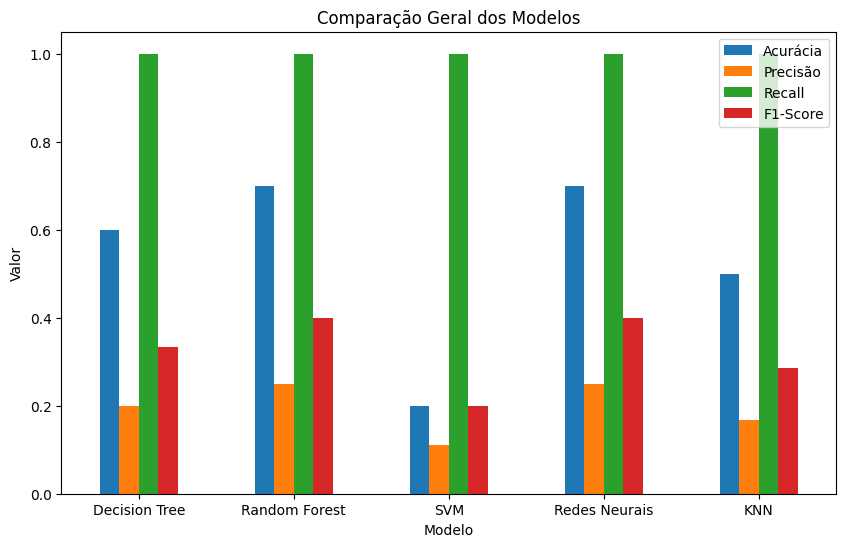

In [590]:
resultado_modelos.set_index('Modelo')[
    ['Acurácia', 'Precisão', 'Recall', 'F1-Score']
].plot(kind='bar', figsize=(10, 6))

plt.title('Comparação Geral dos Modelos')
plt.ylabel('Valor')
plt.xticks(rotation=0)
plt.show()

In [591]:
melhor_modelo = resultado_modelos.loc[
    resultado_modelos['F1-Score'].idxmax()
]

print("Melhor modelo:")
print(melhor_modelo)

Melhor modelo:
Modelo      Random Forest
Acurácia              0.7
Precisão             0.25
Recall                1.0
F1-Score              0.4
Name: 1, dtype: object


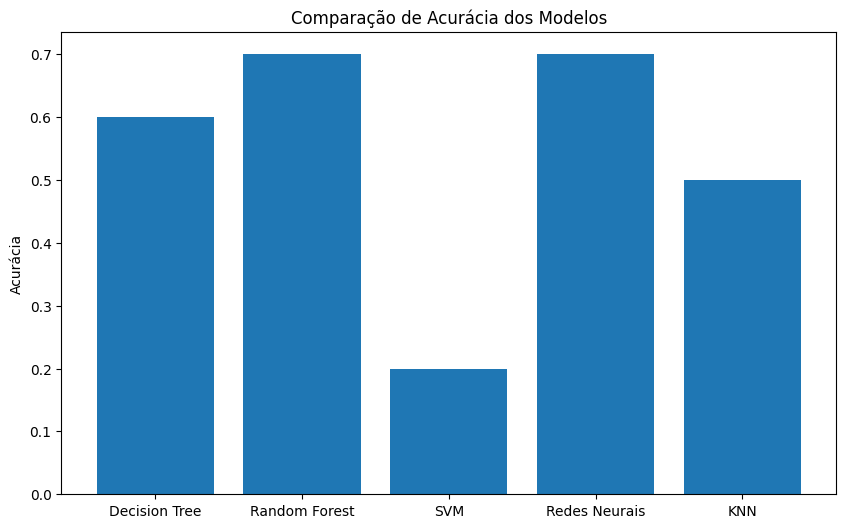

In [592]:
plt.figure(figsize=(10, 6))
plt.bar(resultado_modelos['Modelo'],
        resultado_modelos['Acurácia'])

plt.title('Comparação de Acurácia dos Modelos')
plt.ylabel('Acurácia')
plt.show()

# Pipeline 10 | Conclusões Analíticas

Foram avaliados cinco algortimos de Aprendizagem de Máquina para prever a direção diária das ações da IBM utilizando informações históricas de variação e volume negociado. Todos os modelos foram treinados utilizando a mesma base de dados, a mesma divisão sequencial entre treino e teste e o mesmo processo de normalização, garantindo uma comparação justa e sem vazamento de dados.

Os resultados mostram que o **Random Forest** e as **Redes Neurais** apresentaram o melhor desempenho geral, ambos alcançando **70% de acurácia, 100% de recall e F1-Score de 0,40**. Isso indica que os dois modelos conseguiram identificar corretamente todos os dias de altas presentes nos conjuntos de teste. Entretanto, o **Random Forest** apresenta uma vantagem importante por possuir maior interpretabilidade e menor complexibilidade computacional quando comparado à **Rede Neural**.

A **Árvore de Decisão** apresentou desempenho intermediário, obtendo **60% de acurácia e F1-Score de 0,33**. O resultado sugere que o modelo conseguiu capturar parte dos padrões de generalização quando comparado ao **Random Forest**, que utiliza múltiplas árvores para reduzir a variância das previsões.

O **KNN** alcançou **50% de acurácia e F1-Score de 0,29**. Apesar da utilização do GridSearchCV para encontrar os melhores hiperparâmetros, o modelo apresentou dificuldades em lidar com a dinâmica do mercado financeiro. Como suas previsões dependem da proximidade entre observações, pequenas mudanças no comportamento dos preços podem impactar significativamente seu desempenho.

O **SVM** apresentou o pior resultado entre os modelos avaliados, com **apenas 20% de acurácia e F1-Score de 0,20**. Observando a matriz de confusão, percebe-se que o algoritmo classificou a maior parte das observações como dias de alta, gerando muitos falsos positivos. Esse comportamento sugere que os  padrões presentes na série temporal da IBM não foram adequadamente separados pelo hiperplano construído pelo modelo.

Um aspecto importante observado é que todos os modelos apresentaram um **recall igual a 1,0**, indicando que nenhum deles deixou de identificar os dias de alta existentes no conjunto de teste. Entretanto, a principal diferença entre os algoritmos ocorreu na quantidade de falsos positivos gerados, refletidas nos valores de precisão e F1-Score. Por este motivo, o F1-Score foi utilizado como principal métrica de comparação, pois representa um equilíbrio entre precisão e recall.

Dessa forma, considerando o conjunto de métricas obtidas, o Random Forest demonstrou o melhor equilíbro entre capacidade preditiva, robustez e interpretabilidade, apresentando o melhor desempenho mais consistente para a previsão da direção diária das ações da IBM.